# EMI Prediction

In [1]:
import pandas as pd

emidf=pd.read_csv(r"D:\PY\EMI Predict\emi_prediction_dataset.csv")

C:\Users\DEEPIKA SUNIL\AppData\Local\Temp\ipykernel_7656\3137515500.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  emidf=pd.read_csv(r"D:\PY\EMI Predict\emi_prediction_dataset.csv")


In [2]:
emidf.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38,Female,Married,Professional,82600,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700,660.0,303200,70200.0,Personal Loan EMI,850000,15,Not_Eligible,500.0
1,38,Female,Married,Graduate,21500,Private,7.0,MNC,Family,0.0,...,Yes,4100,714.0,92500,26900.0,E-commerce Shopping EMI,128000,19,Not_Eligible,700.0
2,38,Male,Married,Professional,86100,Private,5.8,Startup,Own,0.0,...,No,0,650.0,672100,324200.0,Education EMI,306000,16,Eligible,27775.0
3,58,Female,Married,High School,66800,Private,2.2,Mid-size,Own,0.0,...,No,0,685.0,440900,178100.0,Vehicle EMI,304000,83,Eligible,16170.0
4,48,Female,Married,Professional,57300,Private,3.4,Mid-size,Family,0.0,...,No,0,770.0,97300,28200.0,Home Appliances EMI,252000,7,Not_Eligible,500.0


In [3]:
# Check the first column name and its unique values
print(f"Column 0 name: {emidf.columns[0]}")
print(emidf.iloc[:, 0].value_counts().head())

Column 0 name: age
age
38    91577
32    75958
48    60748
27    45461
58    30326
Name: count, dtype: int64


In [4]:
emidf.nunique()

age                          33
gender                        8
marital_status                2
education                     4
monthly_salary            13662
employment_type               3
years_of_employment         356
company_type                  5
house_type                    3
monthly_rent               4396
family_size                   5
dependents                    5
school_fees                 132
college_fees                202
travel_expenses             284
groceries_utilities         544
other_monthly_expenses      373
existing_loans                2
current_emi_amount          508
credit_score                427
bank_balance              12261
emergency_fund             5486
emi_scenario                  5
requested_amount           1491
requested_tenure             82
emi_eligibility               3
max_monthly_emi           15383
dtype: int64

In [5]:
# Check the first column name and its unique values
print(f"Column 0 name: {emidf.columns[0]}")
print(emidf.iloc[:, 0].value_counts().head())

Column 0 name: age
age
38    91577
32    75958
48    60748
27    45461
58    30326
Name: count, dtype: int64


In [6]:
emidf.isnull().sum()

age                          0
gender                       0
marital_status               0
education                 2404
monthly_salary               0
employment_type              0
years_of_employment          0
company_type                 0
house_type                   0
monthly_rent              2426
family_size                  0
dependents                   0
school_fees                  0
college_fees                 0
travel_expenses              0
groceries_utilities          0
other_monthly_expenses       0
existing_loans               0
current_emi_amount           0
credit_score              2420
bank_balance              2426
emergency_fund            2351
emi_scenario                 0
requested_amount             0
requested_tenure             0
emi_eligibility              0
max_monthly_emi              0
dtype: int64

In [7]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


# Cleaning Numeric Inconsistencies

In [8]:
def clean_numeric_string(val):
    if pd.isna(val): return val
    if isinstance(val, str):
        # Keeps only the first part before any dots
        val = val.split('.')[0]  # Keep only the part before the first dot
        return val  # Return the cleaned string
    return val  # Return the original value if it's not a string
#  Applying the fix to specific columns
cols_to_fix = ['age', 'monthly_salary', 'bank_balance']
for col in cols_to_fix:
    emidf[col] = emidf[col].apply(clean_numeric_string)
    emidf[col] = pd.to_numeric(emidf[col], errors='coerce')

print("Numeric columns cleaned and converted.")

Numeric columns cleaned and converted.


# Handling Missing Values (Imputation)

In [9]:
# Fill Education blanks with the Mode (Graduate/Professional)
emidf['education']=emidf['education'].fillna(emidf['education'].mode()[0])

# Fill Financial blanks with the Median
finance_cols = ['monthly_rent', 'bank_balance','emergency_fund','credit_score','age','monthly_salary']
for col in finance_cols:
    emidf[col] = emidf[col].fillna(emidf[col].median())

print("Missing values handled.")

Missing values handled.


# Data Validation & Deduplication

In [10]:
# Drop exact duplicates
emidf = emidf.drop_duplicates()

# Filter based on our project rules (Age 25 - 60)
emidf = emidf[(emidf['age'] >= 25) & (emidf['age'] <= 60)]
emidf = emidf[emidf['monthly_salary'] > 0]

print("Duplicates removed and age filtered.")

Duplicates removed and age filtered.


# Train-Test-Validation Split (60-20-20)

In [11]:
# Split 1: 80% for training+validation, 20% for final testing
train_val_df, test_df = train_test_split(
    emidf,
    test_size=0.20,
    random_state=42,
    stratify=emidf['emi_eligibility']
    )

# Split 2: Divide the 80% into Train (60%) and Validation (20%)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.25,
    random_state=42,
    stratify=train_val_df['emi_eligibility']
)

print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Testing set size: {len(test_df)}")

Training set size: 242880
Validation set size: 80960
Testing set size: 80960


In [12]:
print(emidf.isnull().sum().sum()) # Should be 0

0


# STEP2 EDA

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns


In [14]:
# 1. Statistical Summary
print("--- Statistical Summary ---")
print(emidf.describe())

--- Statistical Summary ---
                 age  monthly_salary  years_of_employment   monthly_rent  \
count  404800.000000   404800.000000        404800.000000  404800.000000   
mean       38.875860    59501.887530             5.364079    5793.516126   
std         9.303593    43367.251049             6.079135    8634.376551   
min        26.000000     3967.000000             0.500000       0.000000   
25%        32.000000    35400.000000             1.200000       0.000000   
50%        38.000000    51700.000000             3.200000       0.000000   
75%        48.000000    73000.000000             7.200000   10600.000000   
max        59.000000   499970.000000            36.000000   80000.000000   

         family_size     dependents    school_fees   college_fees  \
count  404800.000000  404800.000000  404800.000000  404800.000000   
mean        2.940425       1.940425    4624.575593    4066.253706   
std         1.075199       1.075199    5061.074401    7319.344289   
min        

# Statistical Summary and Class Distribution

Analyze EMI eligibility distribution patterns across different lending scenarios

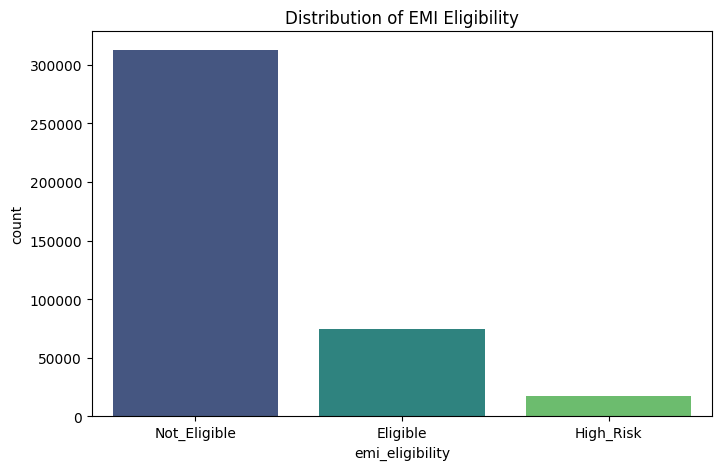

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
# Target variable distribution
plt.figure(figsize=(8,5))
sns.countplot(x='emi_eligibility', data=emidf,palette='viridis',hue=emidf['emi_eligibility'])
plt.title('Distribution of EMI Eligibility')
plt.show()

C:\Users\DEEPIKA SUNIL\AppData\Local\Temp\ipykernel_7656\2827679908.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=emidf, y='emi_scenario', palette='magma')


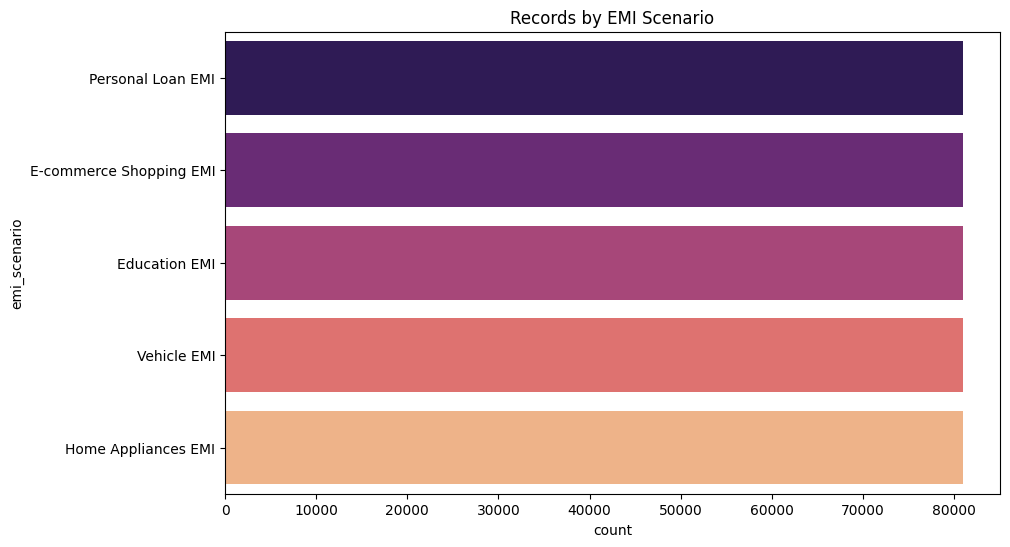

In [16]:
# 2. Distribution across Loan Scenarios
plt.figure(figsize=(10, 6))
sns.countplot(data=emidf, y='emi_scenario', palette='magma')
plt.title('Records by EMI Scenario')
plt.show()

# Study correlation between financial variables and loan approval rates

C:\Users\DEEPIKA SUNIL\AppData\Local\Temp\ipykernel_7656\2299153831.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=emidf, x='emi_eligibility', y='credit_score', palette='coolwarm')


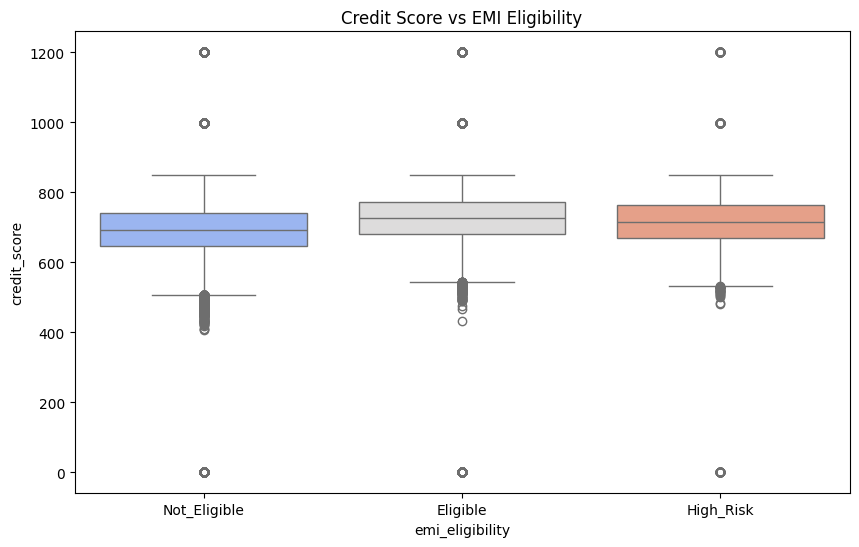

In [17]:
# 4. Correlation between Credit Score and Eligibility
plt.figure(figsize=(10, 6))
sns.boxplot(data=emidf, x='emi_eligibility', y='credit_score', palette='coolwarm')
plt.title('Credit Score vs EMI Eligibility')
plt.savefig('step2_credit_vs_eligibility.png')

Correlation Heatmap

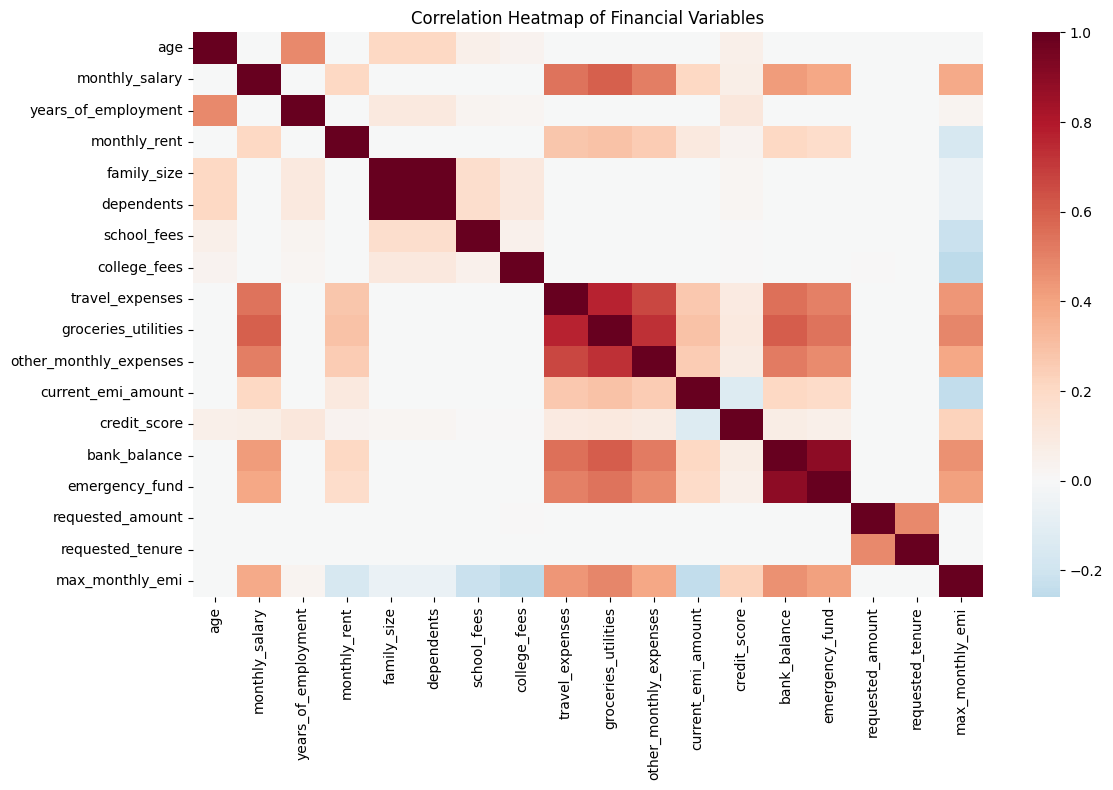

In [18]:
# 5. Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_cols = emidf.select_dtypes(include=[np.number]).columns
correlation_matrix = emidf[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=False, cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap of Financial Variables')
plt.tight_layout()
plt.savefig('step2_correlation_heatmap.png')

EDA visualisations saved.


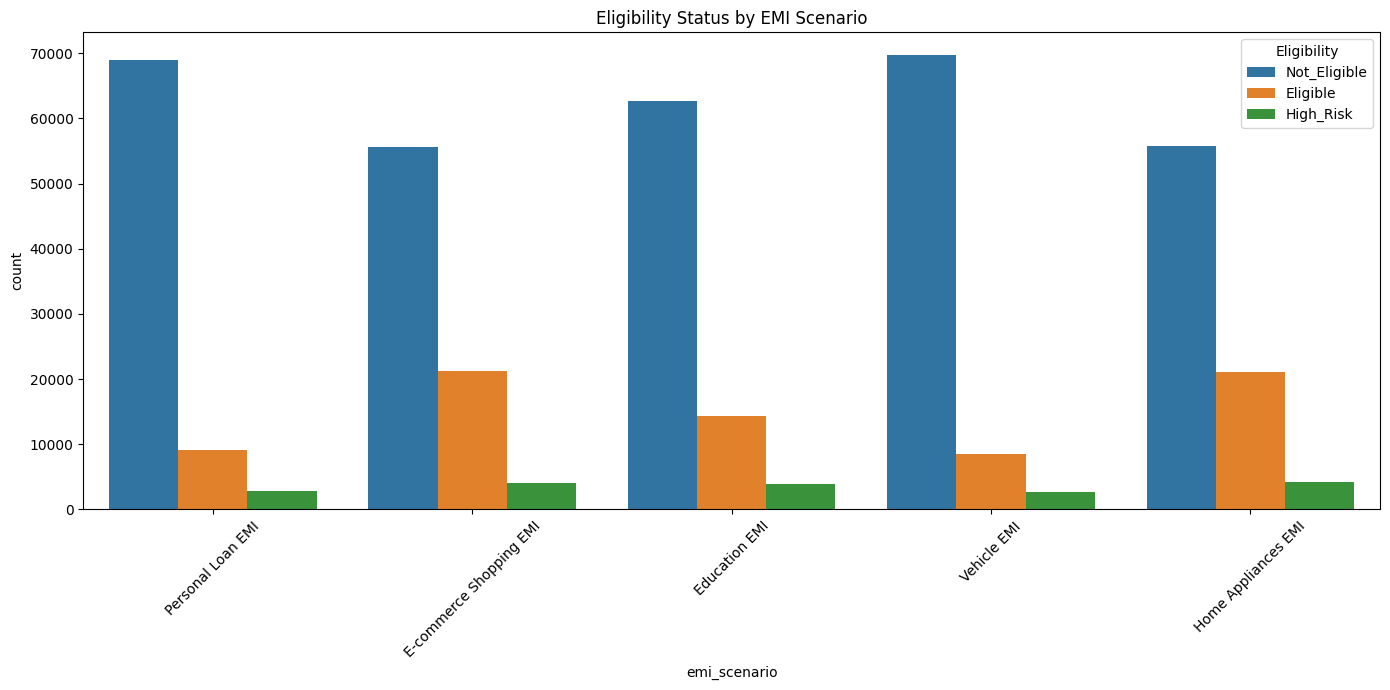

In [19]:
# 6. EMI Eligibility across Scenarios
plt.figure(figsize=(14, 7))
sns.countplot(data=emidf, x='emi_scenario', hue='emi_eligibility')
plt.title('Eligibility Status by EMI Scenario')
plt.xticks(rotation=45)
plt.legend(title='Eligibility', loc='upper right')
plt.tight_layout()
plt.savefig('step2_scenario_vs_eligibility.png')
print("EDA visualisations saved.")

# STEP 3 Feature Engineering

In [20]:
# Calculate total monthly expenditure (Rent+Utilities+Fees)
expense_cols = ["monthly_rent","school_fees","college_fees",'travel_expenses',
                "groceries_utilities","other_monthly_expenses"]
emidf['total_monthly_expenditure'] = emidf[expense_cols].sum(axis=1)

In [21]:
# Debit to income ratio : Current EMI burden relative to salary
emidf['dti_ratio'] = emidf['current_emi_amount'] / emidf['monthly_salary']

In [22]:
# Disposable Income: Amount left after expenses and current EMIs
emidf['disposable_income'] = emidf['monthly_salary'] - emidf['total_monthly_expenditure'] - emidf['current_emi_amount']

In [23]:
# Requested EMI (approximate): amount / tenure
emidf['requested_emi'] = emidf['requested_amount'] / emidf['requested_tenure']

In [24]:
# Potential DTI: (Current EMI + Requested EMI) / Monthly Salary
emidf['potential_dti'] = (emidf['current_emi_amount'] + emidf['requested_emi']) / emidf['monthly_salary']

In [25]:
print("Financial Ratios calculated.")

Financial Ratios calculated.


# Target Label Encoding

the model can't "read" the words "Eligible" or "High_Risk," we convert them into numbers

In [26]:
# mapping the number: 0 for Not Eligible, 1 for High risk,2 for Eligible

target_mapping = {'Not_Eligible': 0, 'High_Risk': 1, 'Eligible': 2}
emidf['emi_eligibility_encoded'] = emidf['emi_eligibility'].map(target_mapping)
print("Target variable encoded with labels.")

Target variable encoded with labels.


# Categorical Column Encoding

In [27]:
# identify the categorical columns
cat_cols = ['gender','marital_status','employment_type','company_type','house_type','existing_loans','emi_scenario']

#Apply one-hot encoding to categorical columns
emidf_final = pd.get_dummies(emidf, columns=cat_cols, drop_first=True)
print("Categorical variables encoded.")

# Note: We keep 'education' separate if we want to treat it as an ordinal (order-based) feature
education_order={'High School': 1, 'Graduate': 2, 'Professional': 3,'Post Graduate': 4}
emidf_final['education_encoded'] = emidf_final['education'].map(education_order)
print("Education variable encoded as ordinal.")

Categorical variables encoded.
Education variable encoded as ordinal.


In [28]:
# Remove the original string columns so the model only sees numbers
cols_to_drop = ['education', 'emi_eligibility', 'gender', 'marital_status'] # Add any remaining string columns
emidf_final = emidf_final.select_dtypes(include=[np.number])

# Step 4: Machine Learning Model Development

In [29]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
X = emidf_final.drop(columns=['emi_eligibility_encoded'])
y = emidf_final['emi_eligibility_encoded']
print(f"Rows available for training: {len(X)}")

Rows available for training: 404800


In [31]:
print(X.isnull().sum())
print(y.isnull().sum())

age                          0
monthly_salary               0
years_of_employment          0
monthly_rent                 0
family_size                  0
dependents                   0
school_fees                  0
college_fees                 0
travel_expenses              0
groceries_utilities          0
other_monthly_expenses       0
current_emi_amount           0
credit_score                 0
bank_balance                 0
emergency_fund               0
requested_amount             0
requested_tenure             0
max_monthly_emi              0
total_monthly_expenditure    0
dti_ratio                    0
disposable_income            0
requested_emi                0
potential_dti                0
education_encoded            0
dtype: int64
0


In [32]:
from sklearn.model_selection import train_test_split
if len(X) > 0:
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print("Success! Data split correctly.")
else:
    print("ERROR: emidf_final is still empty. Check if your filters in Step 1 removed all rows.")

Success! Data split correctly.


Model Accuracy: 0.8929

Detailed Performance Report:
              precision    recall  f1-score   support

Not_Eligible       1.00      0.90      0.95     62574
   High_Risk       0.28      0.96      0.44      3497
    Eligible       0.99      0.83      0.90     14889

    accuracy                           0.89     80960
   macro avg       0.76      0.90      0.76     80960
weighted avg       0.97      0.89      0.92     80960



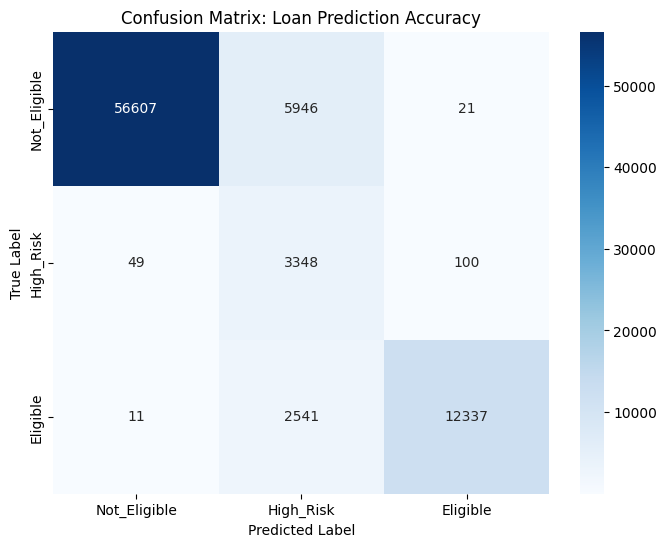

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
# Initialize the model

# 'class_weight=balanced' is vital here to help the AI learn 'High Risk' cases
rf_model = RandomForestClassifier(n_estimators=100,max_depth=10, random_state=42,class_weight='balanced')

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred, target_names=['Not_Eligible', 'High_Risk', 'Eligible']))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not_Eligible', 'High_Risk', 'Eligible'], 
            yticklabels=['Not_Eligible', 'High_Risk', 'Eligible'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Loan Prediction Accuracy')
plt.show()

# Logistic Regression (The Baseline)

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
# Create a pipeline that includes scaling and logistic regression
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000))
    ])
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("--- Logistic Regression Report ---")
print(classification_report(y_test, y_pred_lr))

--- Logistic Regression Report ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     62574
           1       0.61      0.98      0.75      3497
           2       1.00      0.95      0.97     14889

    accuracy                           0.97     80960
   macro avg       0.87      0.97      0.90     80960
weighted avg       0.98      0.97      0.97     80960



XG boost

In [35]:
from xgboost import XGBClassifier

# Initialize XGBoost
# Note: XGBoost expects labels starting from 0 (which our 0, 1, 2 mapping already provides)
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("--- XGBoost Report ---")
print(classification_report(y_test, y_pred_xgb))

c:\Users\DEEPIKA SUNIL\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:19:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     62574
           1       0.87      0.84      0.85      3497
           2       0.98      0.99      0.98     14889

    accuracy                           0.99     80960
   macro avg       0.95      0.94      0.94     80960
weighted avg       0.99      0.99      0.99     80960



# Decision tree

In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,precision_score, recall_score

dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10)

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# F1 Scores

In [37]:
from sklearn.metrics import f1_score

models = {
    "Random Forest": f1_score(y_test, y_pred, average='weighted'), # y_pred from your previous step
    "Logistic Regression": f1_score(y_test, y_pred_lr, average='weighted'),
    "XGBoost": f1_score(y_test, y_pred_xgb, average='weighted'),
    "DecisionTree": f1_score(y_test, y_pred_dt, average='weighted')
}

best_model_name = max(models, key=models.get)
print(f"The best performing classification model is: {best_model_name}")

The best performing classification model is: XGBoost


# Regression

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
import numpy as np

# 1. Prepare Regression Data
# We use the same features (X), but the target is now the numeric max_monthly_emi
y_reg = emidf_final['max_monthly_emi']

# split for regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# initialize and train the regression model
reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

# make predictions
y_pred_reg = reg_model.predict(X_test_reg)

# evaluate regression performance
mse = mean_squared_error(y_test_reg, y_pred_reg)
mae= mean_absolute_error(y_test_reg, y_pred_reg)
rmse= np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("---Linear Regression Performance---")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root mean-squared Error (RMSE): {rmse:.4f}")


---Linear Regression Performance---
Mean Squared Error: 0.00
Mean Absolute Error: 0.00
Root mean-squared Error (RMSE): 0.0000


# (Regression - Model 2): Random Forest Regressor

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score,mean_absolute_percentage_error
import numpy as np

# 1. FIX: Ensure the target is NOT in the features to avoid leakage
X_reg=emidf_final.drop(columns=['emi_eligibility_encoded','max_monthly_emi'],errors='ignore')
y_reg=emidf_final['max_monthly_emi']

# 2.Split the data for regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 3. Train a Random Forest Regressor
# We use a smaller n_estimators and max_depth to speed up training
rf_regressor = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42,n_jobs=-1)
rf_regressor.fit(X_train_reg, y_train_reg)

# 4. Make predictions 
y_pred_rf = rf_regressor.predict(X_test_reg)

# 5. Evaluate the regression model
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf)
mse_rf = mean_squared_error(y_test_reg, y_pred_rf)
r2_rf = r2_score(y_test_reg, y_pred_rf)
mape_rf = mean_absolute_percentage_error(y_test_reg, y_pred_rf)

print("--- Random Forest Regression Performance ---")
print(f"Mean Absolute Error: {mae_rf:.2f}")
print(f"Mean Squared Error: {mse_rf:.2f}")
print(f"R-squared: {r2_rf:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_rf:.2%}")

--- Random Forest Regression Performance ---
Mean Absolute Error: 557.61
Mean Squared Error: 1491821.91
R-squared: 0.9747
Mean Absolute Percentage Error (MAPE): 10.48%


In [40]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score,mean_absolute_percentage_error
import numpy as np

# 1. Prepare Regression Data
xgb_regressor=XGBRegressor(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=10,
    random_state=42,
    objective='reg:squarederror'
    )

# 2. Train the XGBoost Regressor
xgb_regressor.fit(X_train_reg, y_train_reg)
# 3. Make predictions
y_pred_xgb_regressor = xgb_regressor.predict(X_test_reg)

# 4. Evaluate the regression model
mae_xgb = mean_absolute_error(y_test_reg, y_pred_xgb_regressor)
mse_xgb = mean_squared_error(y_test_reg, y_pred_xgb_regressor)
r2_xgb = r2_score(y_test_reg, y_pred_xgb_regressor)
mape_xgb = mean_absolute_percentage_error(y_test_reg, y_pred_xgb_regressor)

print("--- XGBoost Regression Performance ---")
print(f"Mean Absolute Error: {mae_xgb:.2f}")
print(f"Mean Squared Error: {mse_xgb:.2f}")
print(f"R-squared: {r2_xgb:.4f}")
print(f"Mean Absolute Percentage Error: {mape_xgb:.4f}")

--- XGBoost Regression Performance ---
Mean Absolute Error: 459.72
Mean Squared Error: 1205743.65
R-squared: 0.9796
Mean Absolute Percentage Error: 0.1050


# Support Vector & Gradient Boosting Regressors

In [41]:
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1.Support Vector Regressor Pipeline - requires feature scaling
svr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1))
])
#2. Train the SVR model
gbr_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

svr_model.fit(X_train_reg, y_train_reg)
gbr_model.fit(X_train_reg, y_train_reg)

# 4. Make predictions
y_pred_svr = svr_model.predict(X_test_reg)
y_pred_gbr = gbr_model.predict(X_test_reg)

Model Comparison

In [42]:
def evaluate_reg(name,y_true,y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse=np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    return{
        "Model" : name,
        "R-squared": r2,
        "MAE": mae,
        "MSE": mse,
        "MAPE %": mape *100
    }

# Collection of results
reg_results = [
    evaluate_reg("SVR", y_test_reg, y_pred_svr),
    evaluate_reg("Gradient Boosting Regressor", y_test_reg, y_pred_gbr),
    evaluate_reg("XGBoost", y_test_reg, y_pred_xgb_regressor),
    evaluate_reg("Random Forest", y_test_reg, y_pred_rf),
    evaluate_reg("Linear Regression", y_test_reg, y_pred_reg)
]

# Display comparison table
final_comparision_df = pd.DataFrame(reg_results).sort_values(by="R-squared", ascending=False).to_string(index=False)
print("--- Regression Model Performance Comparison ---")
print(final_comparision_df)

--- Regression Model Performance Comparison ---
                      Model  R-squared          MAE          MSE       MAPE %
          Linear Regression   1.000000 5.512227e-11 5.150643e-21 3.679374e-12
                    XGBoost   0.979576 4.597221e+02 1.205744e+06 1.049644e+01
Gradient Boosting Regressor   0.978734 5.134800e+02 1.255462e+06 1.472591e+01
              Random Forest   0.974730 5.576062e+02 1.491822e+06 1.047721e+01
                        SVR   0.857783 1.288160e+03 8.395984e+06 4.748848e+01


# ML Flow

In [43]:
import mlflow

mlflow.set_tracking_uri("http://localhost:5001")

mlflow.set_experiment("EMI_Eligibility_Project")

print("MLflow is ready to track your experiments!")

MlflowException: API request to http://localhost:5001/api/2.0/mlflow/experiments/get-by-name failed with exception HTTPConnectionPool(host='localhost', port=5001): Max retries exceeded with url: /api/2.0/mlflow/experiments/get-by-name?experiment_name=EMI_Eligibility_Project (Caused by NewConnectionError("HTTPConnection(host='localhost', port=5001): Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it"))

In [ ]:
from mlflow.models import infer_signature
from sklearn.metrics import accuracy_score, f1_score, r2_score, mean_absolute_error

In [ ]:
from sklearn.metrics import f1_score

classification_models = {
    "Random Forest": f1_score(y_test, y_pred, average='weighted'), # y_pred from your previous step
    "Logistic Regression": f1_score(y_test, y_pred_lr, average='weighted'),
    "XGBoost": f1_score(y_test, y_pred_xgb, average='weighted'),
    "DecisionTree": f1_score(y_test, y_pred_dt, average='weighted')
}

best_model_name = max(models, key=models.get)
print(f"The best performing classification model is: {best_model_name}")

NameError: name 'y_test' is not defined

In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, f1_score, r2_score, mean_absolute_error, mean_absolute_percentage_error

mlflow.set_experiment("EMI_Loan_Project_v1")

# --- 1. Classification Logging (Select Best 3) ---
classification_models = {
    "Random_Forest_Classifier": rf_model, 
    "Logistic_Regression": lr_model,
    "XGBoost_Classifier": xgb_model
}

for name, model in classification_models.items():
    with mlflow.start_run(run_name=name):
        y_pred = model.predict(X_test)
        
        # Log Metrics
        mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred))
        mlflow.log_metric("f1_weighted", f1_score(y_test, y_pred, average='weighted'))
        
        # Log Artifact (Save the model file)
        mlflow.sklearn.log_model(model, "model")
        print(f"Logged Classification: {name}")

# --- 2. Regression Logging (Select Best 3) ---
regression_models = {
    "Linear_Regression": reg_model,
    "XGBoost_Regressor": xgb_regressor,
    "Gradient_Boosting_Reg": gbr_model
}

for name, reg in regression_models.items():
    with mlflow.start_run(run_name=name):
        y_pred_reg = reg.predict(X_test_reg)
        
        # Log Metrics
        mlflow.log_metric("R2_Score", r2_score(y_test_reg, y_pred_reg))
        mlflow.log_metric("MAE", mean_absolute_error(y_test_reg, y_pred_reg))
        
        # Log Artifact
        mlflow.sklearn.log_model(reg, "reg_model")
        print(f"Logged Regression: {name}")

NameError: name 'rf_model' is not defined

In [ ]:
import mlflow

mlflow.set_experiment("MLflow Quickstart")